# Almgren-Chriss Optimal Execution

**Docker image**: `ml4t`

This notebook implements the Almgren-Chriss (2001) framework for optimal trade
execution: closed-form trajectories, the efficient frontier of execution
strategies, and a Transaction Cost Analysis (TCA) demonstration.

**Learning Objectives**
- Understand the market impact vs timing risk trade-off
- Implement the Almgren-Chriss closed-form solution for optimal trajectories
- Compute the efficient frontier of execution strategies
- Perform Monte Carlo simulation and produce a basic TCA report

**Book Reference:** Chapter 18, Section 18.6 (Optimizing Execution with
Almgren-Chriss as a Unifying Framework)

**Prerequisites:** Read [`04_vwap_twap_execution`](04_vwap_twap_execution.ipynb)
for benchmark schedules and
[`03_market_impact_calibration`](03_market_impact_calibration.ipynb) for the
empirical interpretation of the impact inputs.

## The Optimal Execution Problem

When liquidating a position, we face two competing costs:

1. **Market Impact**: Trading fast moves prices against us
2. **Timing Risk**: Trading slow exposes us to price volatility

The Almgren-Chriss model finds the **optimal trade-off** between these costs.

## Imports & Settings

In [1]:
"""Almgren-Chriss Optimal Execution - Efficient frontier, optimal trajectories, and TCA."""

import warnings
from dataclasses import dataclass

warnings.filterwarnings("ignore")

import numpy as np
import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

from utils.reproducibility import set_global_seeds

In [2]:
N_RISK_AVERSIONS = 100  # Points along the efficient frontier (risk-aversion sweep)
SEED = 42
N_SIMULATIONS = 1000

In [3]:
set_global_seeds(SEED)

## Part 1: Model Setup

### Price Dynamics

The stock price evolves as:
$$S_k = S_{k-1} + \sigma \tau^{1/2} \xi_k - g(n_k)$$

where:
- $S_k$ = price after period $k$
- $\sigma$ = volatility
- $\tau$ = time step
- $\xi_k \sim N(0,1)$ = random shock
- $g(n_k)$ = permanent impact of trading $n_k$ shares

### Impact Functions

**Permanent Impact** (information):
$$g(n) = \gamma n$$

**Temporary Impact** (liquidity):
$$h(n) = \epsilon \, \text{sign}(n) + \eta \frac{n}{\tau}$$

In [4]:
@dataclass
class AlmgrenChrissParams:
    """Parameters for Almgren-Chriss model."""

    # Position
    X: int = 100_000  # Initial shares to liquidate
    T: float = 1.0  # Trading horizon (days)
    N: int = 10  # Number of trading periods

    # Market parameters
    S0: float = 100.0  # Initial price
    sigma: float = 0.30  # Annual volatility

    # Impact parameters
    gamma: float = 0.05  # Permanent impact (bps per share / ADV)
    eta: float = 0.10  # Temporary impact (bps per share / ADV)
    epsilon: float = 5.0  # Fixed cost / half-spread component (bps)

    # Volume
    ADV: float = 1_000_000  # Average daily volume

    @property
    def tau(self) -> float:
        """Time step."""
        return self.T / self.N

    @property
    def sigma_daily(self) -> float:
        """Daily volatility."""
        return self.sigma / np.sqrt(252)

    def __post_init__(self):
        """Convert impact parameters to price units."""
        # Convert from bps to price impact per share
        self.gamma_price = self.gamma * self.S0 / (self.ADV * 10000)
        self.eta_price = self.eta * self.S0 / (self.ADV * 10000)
        self.epsilon_price = self.epsilon * self.S0 / 10000

In [5]:
# Default parameters
params = AlmgrenChrissParams(
    X=100_000,
    T=5.0,  # 5 days
    N=50,  # 50 periods
    S0=100.0,
    sigma=0.30,
    gamma=0.05,
    eta=0.10,
    epsilon=5.0,  # 5 bps half-spread
    ADV=1_000_000,
)

print("Almgren-Chriss Parameters")
print("=" * 50)
print(f"Position:          {params.X:,} shares (${params.X * params.S0 / 1e6:.1f}M)")
print(f"Horizon:           {params.T} days ({params.N} periods)")
print(f"ADV:               {params.ADV:,} shares")
print(f"Participation:     {params.X / (params.ADV * params.T):.1%} of volume")
print(f"Daily Volatility:  {params.sigma_daily:.2%}")
print(f"Permanent γ:       {params.gamma} bps/share")
print(f"Temporary η:       {params.eta} bps/share")

Almgren-Chriss Parameters
Position:          100,000 shares ($10.0M)
Horizon:           5.0 days (50 periods)
ADV:               1,000,000 shares
Participation:     2.0% of volume
Daily Volatility:  1.89%
Permanent γ:       0.05 bps/share
Temporary η:       0.1 bps/share


**Finding**: These parameters define the whole execution problem. Once position
size, horizon, liquidity, and volatility are fixed, the notebook is solving for
the least painful way to trade, not whether the trade itself is profitable.

## Part 2: Execution Cost and Risk

### Expected Cost (Implementation Shortfall)

$$E[C] = \frac{1}{2} \gamma X^2 + \epsilon X + \eta \sum_{k=1}^{N} \frac{n_k^2}{\tau}$$

where $n_k$ is shares traded in period $k$.

### Execution Risk (Variance)

$$V[C] = \sigma^2 \sum_{k=1}^{N} \tau \, x_k^2$$

where $x_k$ is remaining position at time $k$.

In [6]:
def compute_trajectory_from_list(trade_list: np.ndarray, X: int) -> np.ndarray:
    """Convert trade list to position trajectory."""
    trajectory = np.zeros(len(trade_list) + 1)
    trajectory[0] = X
    for k, n in enumerate(trade_list):
        trajectory[k + 1] = trajectory[k] - n
    return trajectory

#### Expected Cost Functional

In [7]:
def expected_cost(
    trade_list: np.ndarray,
    params: AlmgrenChrissParams,
) -> float:
    """Compute expected cost (implementation shortfall)."""
    X = params.X
    tau = params.tau
    gamma = params.gamma_price
    eta = params.eta_price
    epsilon = params.epsilon_price

    # Permanent impact (half affects our trades)
    perm_cost = 0.5 * gamma * X**2

    # Fixed cost
    fixed_cost = epsilon * abs(X)

    # Temporary impact
    temp_cost = eta * np.sum(trade_list**2) / tau

    return perm_cost + fixed_cost + temp_cost

#### Execution Variance Functional

In [8]:
def execution_variance(
    trade_list: np.ndarray,
    params: AlmgrenChrissParams,
) -> float:
    """Compute execution variance (timing risk)."""
    trajectory = compute_trajectory_from_list(trade_list, params.X)
    sigma = params.sigma_daily
    tau = params.tau

    # Position risk at each step (excluding final zero position)
    return sigma**2 * tau * np.sum(trajectory[:-1] ** 2)

#### Execution Standard Deviation Helper

In [9]:
def execution_std(trade_list: np.ndarray, params: AlmgrenChrissParams) -> float:
    """Compute execution standard deviation."""
    return np.sqrt(execution_variance(trade_list, params))

In [10]:
# Example: Compare TWAP to aggressive execution
twap_trades = np.full(params.N, params.X / params.N)

aggressive_trades = np.zeros(params.N)
aggressive_trades[0] = params.X  # All in first period

gradual_trades = np.zeros(params.N)
gradual_trades[:5] = params.X / 5  # First 5 periods

strategies = {
    "TWAP": twap_trades,
    "Aggressive": aggressive_trades,
    "Front-loaded": gradual_trades,
}

strategy_comparison = pl.DataFrame(
    [
        {
            "strategy": name,
            "expected_cost_usd": expected_cost(trades, params),
            "cost_std_usd": execution_std(trades, params),
            "cost_risk_ratio": (
                expected_cost(trades, params) / execution_std(trades, params)
                if execution_std(trades, params) > 0
                else float("inf")
            ),
        }
        for name, trades in strategies.items()
    ]
)
strategy_comparison

strategy,expected_cost_usd,cost_std_usd,cost_risk_ratio
str,f64,f64,f64
"""TWAP""",5004.5,2476.316389,2.020945
"""Aggressive""",5102.5,597.614305,8.538116
"""Front-loaded""",5022.5,886.40526,5.666144


**Finding**: The strategy table makes the mean-variance trade-off tangible before
any optimization occurs. TWAP is not optimal by definition; it is simply one
point in the cost-risk space.

## Part 3: Optimal Trajectory

### Mean-Variance Optimization

The trader minimizes:
$$\min_{n_1, ..., n_N} E[C] + \lambda V[C]$$

where $\lambda$ is the risk aversion parameter.

### Closed-Form Solution

The optimal trajectory has the form:
$$x_k = X \frac{\sinh(\kappa(T - t_k))}{\sinh(\kappa T)}$$

where $\kappa = \sqrt{\frac{\lambda \sigma^2}{\eta}}$ captures the trade-off.

In [11]:
def optimal_trajectory(
    params: AlmgrenChrissParams,
    risk_aversion: float,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute optimal Almgren-Chriss trajectory.

    Parameters
    ----------
    params : AlmgrenChrissParams
    risk_aversion : float
        Risk aversion parameter λ (higher = more aggressive)

    Returns
    -------
    times : array
        Time points
    trajectory : array
        Optimal position at each time
    """
    X = params.X
    T = params.T
    N = params.N
    tau = params.tau
    sigma = params.sigma_daily
    eta = params.eta_price

    # Kappa determines trajectory shape
    if risk_aversion > 0 and eta > 0:
        kappa = np.sqrt(risk_aversion * sigma**2 / eta)
    else:
        kappa = 0.001  # Nearly TWAP

    # Time points
    times = np.linspace(0, T, N + 1)

    # Optimal position trajectory
    if abs(kappa * T) < 0.01:
        # Small kappa: nearly linear (TWAP-like)
        trajectory = X * (1 - times / T)
    else:
        a = kappa * (T - times)
        b = kappa * T
        numerator = np.exp(a - b) * (1 - np.exp(-2 * a))
        denominator = 1 - np.exp(-2 * b)
        trajectory = X * numerator / denominator

    return times, trajectory

#### Convert Trajectory to Trade List

In [12]:
def trajectory_to_trades(trajectory: np.ndarray) -> np.ndarray:
    """Convert position trajectory to trade list."""
    return -np.diff(trajectory)

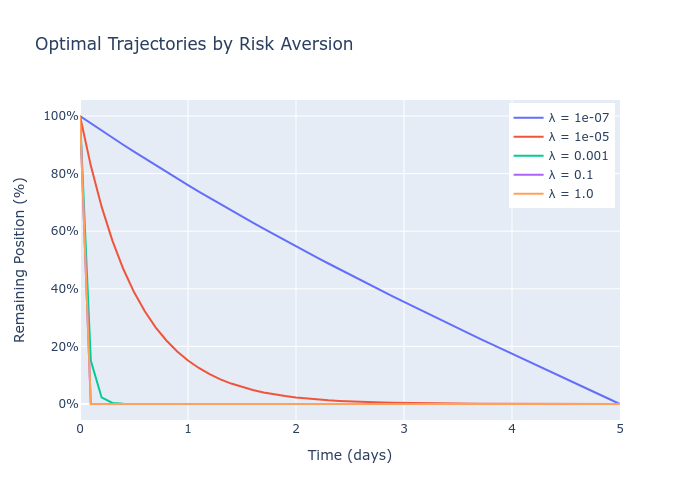

In [13]:
# Compare trajectories for different risk aversions. With the default
# (γ, η) calibration most λ ≥ 1e-3 collapse to near-instant liquidation, so
# this sweep extends to smaller λ values to make the TWAP→front-loaded
# spectrum visible on the plot.
risk_aversions = [1e-7, 1e-5, 1e-3, 1e-1, 1.0]

fig = go.Figure()

for lambda_ in risk_aversions:
    times, traj = optimal_trajectory(params, lambda_)
    fig.add_scatter(
        x=times,
        y=traj / params.X,
        mode="lines",
        name=f"λ = {lambda_}",
        line=dict(width=2),
    )

fig.update_layout(
    title="Optimal Trajectories by Risk Aversion",
    xaxis_title="Time (days)",
    yaxis_title="Remaining Position (%)",
    yaxis_tickformat=".0%",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="right", x=0.99),
)
fig.show()

**Finding**: As risk aversion rises, the trajectory bends forward and empties the
book faster. In Almgren-Chriss, urgency is not a story the trader tells; it is a
parameter that literally reshapes the schedule.

## Part 4: Efficient Frontier of Execution

For each level of expected cost, there's a minimum variance trajectory.
The locus of these points forms the **efficient frontier**.

In [14]:
def compute_efficient_frontier(
    params: AlmgrenChrissParams,
    n_points: int = 50,
) -> pl.DataFrame:
    """Compute the efficient frontier of execution strategies."""
    # Range of risk aversions
    lambdas = np.logspace(-4, 2, n_points)

    results = []
    for lambda_ in lambdas:
        times, traj = optimal_trajectory(params, lambda_)
        trades = trajectory_to_trades(traj)

        cost = expected_cost(trades, params)
        risk = execution_std(trades, params)

        results.append(
            {
                "lambda": lambda_,
                "expected_cost": cost,
                "cost_bps": cost / (params.X * params.S0) * 10000,
                "risk_std": risk,
                "risk_bps": risk / (params.X * params.S0) * 10000,
                "sharpe_like": cost / risk if risk > 0 else np.inf,
            }
        )

    return pl.DataFrame(results)

In [15]:
frontier = compute_efficient_frontier(params, n_points=N_RISK_AVERSIONS)

# Three λ points to annotate on the frontier. The IS-distribution simulation
# below uses a different λ trio (1e-7 / 1e-3 / 1e-1) calibrated for that figure;
# the frontier sweep here is np.logspace(-4, 2, N_RISK_AVERSIONS), so we mark
# three points inside that range and print λ explicitly so a reader does not
# conflate frontier markers with IS-sim regime labels.
strategies_to_mark = [
    (0.001, "Risk-Neutral (λ=1e-3, TWAP-like)"),
    (0.1, "Moderate (λ=1e-1)"),
    (10.0, "Risk-Averse (λ=1e1, Aggressive)"),
]

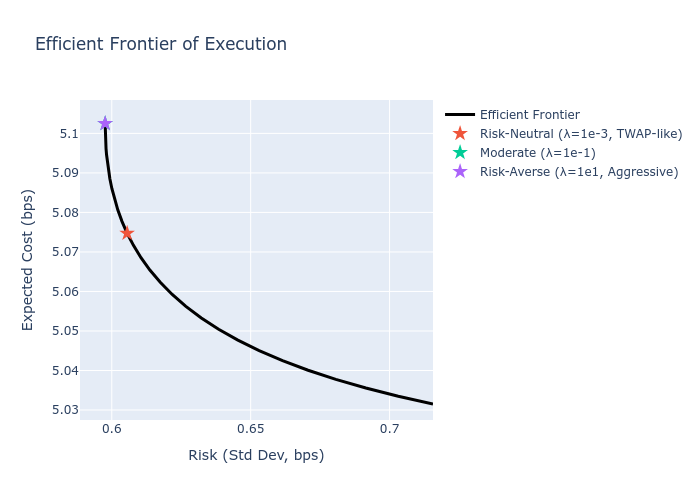

In [16]:
# Build the full annotated figure in one cell so that no intermediate
# add_scatter return value auto-displays a half-built chart (split-cell
# figure bug — see feedback_split_cell_figure_bug).
fig = go.Figure()
fig.add_scatter(
    x=frontier["risk_bps"].to_list(),
    y=frontier["cost_bps"].to_list(),
    mode="lines",
    name="Efficient Frontier",
    line=dict(color="black", width=3),
)
for lambda_, name in strategies_to_mark:
    row = frontier.filter(pl.col("lambda").is_between(lambda_ * 0.9, lambda_ * 1.1))
    if len(row) > 0:
        fig.add_scatter(
            x=[row["risk_bps"][0]],
            y=[row["cost_bps"][0]],
            mode="markers",
            marker=dict(size=12, symbol="star"),
            name=name,
        )
fig.update_layout(
    title="Efficient Frontier of Execution",
    xaxis_title="Risk (Std Dev, bps)",
    yaxis_title="Expected Cost (bps)",
    height=500,
)
fig.show()

In [17]:
print("Frontier Statistics:")
print(
    f"  Min Cost: {frontier['cost_bps'].min():.1f} bps (at {frontier['risk_bps'].max():.1f} bps risk)"
)
print(
    f"  Min Risk: {frontier['risk_bps'].min():.1f} bps (at {frontier['cost_bps'].max():.1f} bps cost)"
)

Frontier Statistics:
  Min Cost: 5.0 bps (at 0.7 bps risk)
  Min Risk: 0.6 bps (at 5.1 bps cost)


**Finding**: The frontier makes the optimization problem explicit. There is no
single best trajectory; each point is a different compromise between paying
impact now and bearing price uncertainty over the rest of the schedule.

## Part 5: Simulation and TCA

Let's simulate actual execution and perform Transaction Cost Analysis.

In [18]:
def simulate_single_execution(
    params: AlmgrenChrissParams,
    trade_list: np.ndarray,
    shocks: np.ndarray,
) -> dict:
    """Simulate one execution path under Almgren-Chriss price dynamics.

    `shocks` is a pre-generated array of standard-normal draws (one per period)
    so that different strategies can be evaluated against the *same* price path
    for a given simulation index — a paired Monte Carlo design that removes
    sampling noise from the strategy comparison.
    """
    tau = params.tau
    sigma = params.sigma_daily
    gamma = params.gamma_price
    eta = params.eta_price
    epsilon = params.epsilon_price
    price = params.S0
    total_cost = 0.0
    total_shares = 0
    prices = [price]

    for k, n_k in enumerate(trade_list):
        price = price - gamma * n_k
        exec_price = price + epsilon + eta * n_k / tau
        total_cost += exec_price * n_k
        total_shares += n_k
        price = price + sigma * np.sqrt(tau) * shocks[k]
        prices.append(price)

    vwap = total_cost / total_shares if total_shares > 0 else params.S0
    is_dollar = total_cost - params.S0 * params.X
    is_bps = is_dollar / (params.S0 * params.X) * 10000
    arrival_shortfall = (vwap / prices[0] - 1) * 10000
    return {
        "vwap": vwap,
        "final_price": prices[-1],
        "is_dollar": is_dollar,
        "is_bps": is_bps,
        "arrival_shortfall_bps": arrival_shortfall,
        "total_cost": total_cost,
    }

### Monte Carlo Wrapper for Execution Paths

In [19]:
def simulate_execution(
    params: AlmgrenChrissParams,
    trade_list: np.ndarray,
    n_simulations: int = 1000,
    seed: int = SEED,
) -> pl.DataFrame:
    """
    Simulate execution with price dynamics.

    Each simulation index `sim` draws its shock array from
    ``np.random.default_rng(seed + sim)`` so that calling this function for
    different strategies reuses the *same* price path per index (paired design).

    Returns
    -------
    DataFrame with simulation results
    """
    results = []

    for sim in range(n_simulations):
        rng = np.random.default_rng(seed + sim)
        shocks = rng.standard_normal(len(trade_list))
        result = simulate_single_execution(params, trade_list, shocks)
        result["simulation"] = sim
        results.append(result)

    return pl.DataFrame(results)

In [20]:
# Compare simulated performance of different strategies
simulation_results = {}

for name, risk_aversion in [
    ("Risk-Neutral (λ=1e-7, near-TWAP)", 1e-7),
    ("Balanced (λ=1e-3)", 1e-3),
    ("Risk-Averse (λ=1e-1, front-loaded)", 1e-1),
]:
    times, traj = optimal_trajectory(params, risk_aversion)
    trades = trajectory_to_trades(traj)
    sim_df = simulate_execution(params, trades, n_simulations=N_SIMULATIONS)
    simulation_results[name] = sim_df

#### TCA Summary Statistics

In [21]:
# Summary statistics as a Polars DataFrame
tca_summary = pl.DataFrame(
    [
        {
            "strategy": name,
            "is_mean_bps": df["is_bps"].mean(),
            "is_std_bps": df["is_bps"].std(),
            "is_p5_bps": df["is_bps"].quantile(0.05),
            "is_p95_bps": df["is_bps"].quantile(0.95),
        }
        for name, df in simulation_results.items()
    ]
)
tca_summary

strategy,is_mean_bps,is_std_bps,is_p5_bps,is_p95_bps
str,f64,f64,f64,f64
"""Risk-Neutral (λ=1e-7, near-TWA…",5.063503,2.256201,1.419396,8.76242
"""Balanced (λ=1e-3)""",5.069519,0.09068,4.921967,5.21817
"""Risk-Averse (λ=1e-1, front-loa…",5.095,3.6552e-9,5.095,5.095


**Finding**: The TCA summary is where the model meets desk reality. The 5th and
95th percentiles matter because execution desks are judged on bad days as much
as on the average path.

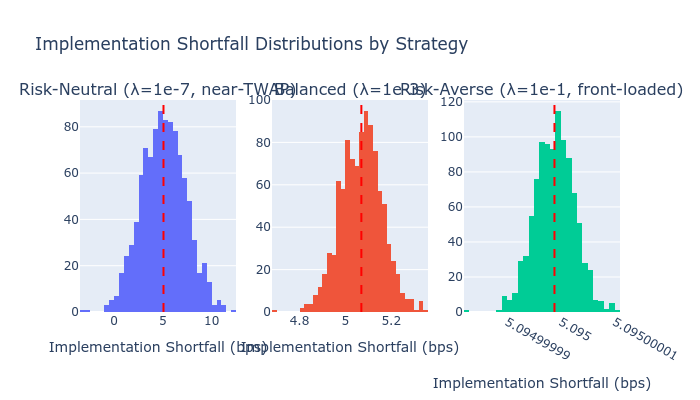

In [22]:
# Visualize distributions
fig = make_subplots(rows=1, cols=3, subplot_titles=list(simulation_results.keys()))

for i, (name, df) in enumerate(simulation_results.items()):
    fig.add_histogram(
        x=df["is_bps"].to_list(),
        nbinsx=50,
        name=name,
        row=1,
        col=i + 1,
    )

    # Add mean line
    mean_is = df["is_bps"].mean()
    fig.add_vline(x=mean_is, line_dash="dash", line_color="red", row=1, col=i + 1)

fig.update_xaxes(title_text="Implementation Shortfall (bps)")
fig.update_layout(
    title="Implementation Shortfall Distributions by Strategy",
    height=400,
    showlegend=False,
)
fig.show()

**Finding**: The histogram makes the hidden cost of urgency visible. Aggressive
schedules reduce exposure time, but they compress more trading into the early
buckets and widen the implementation-shortfall distribution.

## Part 6: Practical Extensions

### Extensions to Basic Model

1. **Non-linear impact**: Replace $h(n) = \eta n$ with $h(n) = \eta |n|^{1/2}$
2. **Time-varying liquidity**: $\eta(t)$ varies intraday
3. **Stochastic volatility**: $\sigma(t)$ varies with regime
4. **Urgency**: Trader may have alpha that decays

#### Non-Linear Impact Extension

In [23]:
@dataclass
class ExtendedParams(AlmgrenChrissParams):
    """Extended parameters with non-linear impact."""

    impact_exponent: float = 0.5  # For square-root impact

#### Non-Linear Cost Functional

In [24]:
def expected_cost_nonlinear(
    trade_list: np.ndarray,
    params: ExtendedParams,
) -> float:
    """Expected cost with square-root temporary impact."""
    X = params.X
    tau = params.tau
    gamma = params.gamma_price
    eta = params.eta_price
    epsilon = params.epsilon_price
    alpha = params.impact_exponent

    # Permanent impact
    perm_cost = 0.5 * gamma * X**2

    # Fixed cost
    fixed_cost = epsilon * abs(X)

    # Non-linear temporary impact: η * |n|^α * n / τ
    temp_cost = eta * np.sum(np.abs(trade_list) ** alpha * trade_list) / tau

    return perm_cost + fixed_cost + temp_cost

In [25]:
# Compare linear vs non-linear impact
extended_params = ExtendedParams(
    X=100_000,
    T=5.0,
    N=50,
    S0=100.0,
    sigma=0.30,
    gamma=0.05,
    eta=0.10,
    epsilon=5.0,  # 5 bps half-spread
    ADV=1_000_000,
    impact_exponent=0.5,
)

# TWAP trades
twap_trades = np.full(extended_params.N, extended_params.X / extended_params.N)

linear_cost = expected_cost(twap_trades, params)
nonlinear_cost = expected_cost_nonlinear(twap_trades, extended_params)

print("Impact Model Comparison (TWAP)")
print("=" * 50)
print(f"Linear Impact:     ${linear_cost:,.0f}")
print(f"Square-Root Impact: ${nonlinear_cost:,.0f}")
print(f"Difference:        {(nonlinear_cost / linear_cost - 1) * 100:+.1f}%")

Impact Model Comparison (TWAP)
Linear Impact:     $5,004
Square-Root Impact: $5,003
Difference:        -0.0%


**Finding**: The non-linear impact comparison is a reminder that execution cost
is not proportional to size at the parent-order level. Splitting flow matters
precisely because marginal impact grows more slowly than linearly.

## Part 7: Transaction Cost Analysis (TCA) Dashboard

A comprehensive TCA report includes:
1. **Cost breakdown**: Impact, spread, timing
2. **Benchmark comparison**: vs VWAP, arrival, close
3. **Attribution**: By time, size, urgency

In [26]:
def generate_tca_report(
    executed_trades: pl.DataFrame,
    benchmark_prices: dict,
    params: AlmgrenChrissParams,
) -> dict:
    """
    Generate TCA report.

    Parameters
    ----------
    executed_trades : DataFrame
        Columns: time, shares, exec_price
    benchmark_prices : dict
        arrival, vwap, close prices
    params : Model parameters

    Returns
    -------
    dict : TCA metrics
    """
    total_shares = executed_trades["shares"].sum()
    total_cost = (executed_trades["shares"] * executed_trades["exec_price"]).sum()
    avg_price = total_cost / total_shares

    arrival = benchmark_prices["arrival"]
    vwap = benchmark_prices["vwap"]
    close = benchmark_prices["close"]

    return {
        "total_shares": total_shares,
        "total_value": total_cost,
        "avg_exec_price": avg_price,
        # Vs benchmarks
        "vs_arrival_bps": (avg_price / arrival - 1) * 10000,
        "vs_vwap_bps": (avg_price / vwap - 1) * 10000,
        "vs_close_bps": (avg_price / close - 1) * 10000,
        # Breakdown — epsilon is already expressed in bps (half-spread)
        "spread_cost_bps": params.epsilon,
        "impact_cost_bps": (avg_price / arrival - 1) * 10000 - params.epsilon,
    }

In [27]:
# Example TCA
example_trades = pl.DataFrame(
    {
        "time": list(range(10)),
        "shares": [10000] * 10,
        "exec_price": [
            100.02,
            100.05,
            100.08,
            100.06,
            100.09,
            100.12,
            100.10,
            100.08,
            100.11,
            100.15,
        ],
    }
)

In [28]:
benchmarks = {
    "arrival": 100.00,
    "vwap": 100.08,
    "close": 100.12,
}

tca = generate_tca_report(example_trades, benchmarks, params)

In [29]:
tca_report = pl.DataFrame(
    [
        {"metric": "Total shares", "value": f"{tca['total_shares']:,}"},
        {"metric": "Total value ($)", "value": f"{tca['total_value']:,.0f}"},
        {"metric": "Avg execution price ($)", "value": f"{tca['avg_exec_price']:.4f}"},
        {"metric": "vs Arrival (bps)", "value": f"{tca['vs_arrival_bps']:+.1f}"},
        {"metric": "vs VWAP (bps)", "value": f"{tca['vs_vwap_bps']:+.1f}"},
        {"metric": "vs Close (bps)", "value": f"{tca['vs_close_bps']:+.1f}"},
        {"metric": "Spread cost (bps)", "value": f"{tca['spread_cost_bps']:.1f}"},
        {"metric": "Impact cost (bps)", "value": f"{tca['impact_cost_bps']:.1f}"},
    ]
)
tca_report

metric,value
str,str
"""Total shares""","""100,000"""
"""Total value ($)""","""10,008,600"""
"""Avg execution price ($)""","""100.0860"""
"""vs Arrival (bps)""","""+8.6"""
"""vs VWAP (bps)""","""+0.6"""
"""vs Close (bps)""","""-3.4"""
"""Spread cost (bps)""","""5.0"""
"""Impact cost (bps)""","""3.6"""


**Interpretation**: TCA closes the loop between model and implementation. Once the
desk can separate spread, impact, and benchmark slippage, it can decide whether
the next improvement should come from smarter scheduling or better venue access.

## Summary

### Almgren-Chriss Framework

1. **The Trade-off**: Market impact vs timing risk
2. **Optimal Solution**: Closed-form trajectory based on risk aversion λ
3. **Efficient Frontier**: Minimum risk for each cost level

### Key Parameters

| Parameter | Meaning | Effect |
|-----------|---------|--------|
| λ | Risk aversion | Higher = more aggressive |
| γ | Permanent impact | Information content of trade |
| η | Temporary impact | Liquidity consumption |
| σ | Volatility | Timing risk |

### Practical Guidelines

1. **Estimate parameters** from historical execution data
2. **Choose λ** based on urgency (alpha decay)
3. **Monitor execution** and adjust for market conditions
4. **Use TCA** to improve future executions

### Extensions

- Non-linear impact (square-root)
- Time-varying parameters
- Multi-asset execution
- Reinforcement learning approaches

In [30]:
print("Efficient frontier computed:")
frontier

Efficient frontier computed:


lambda,expected_cost,cost_bps,risk_std,risk_bps,sharpe_like
f64,f64,f64,f64,f64,f64
0.0001,5031.522061,5.031522,715.633787,0.715634,7.030862
0.000115,5033.486957,5.033487,703.120205,0.70312,7.158786
0.000132,5035.564799,5.035565,691.46663,0.691467,7.282441
0.000152,5037.75769,5.037758,680.653414,0.680653,7.401355
0.000175,5040.066736,5.040067,670.660441,0.67066,7.51508
…,…,…,…,…,…
57.223677,5102.5,5.1025,597.614305,0.597614,8.538116
65.793322,5102.5,5.1025,597.614305,0.597614,8.538116
75.646333,5102.5,5.1025,597.614305,0.597614,8.538116


**Interpretation**: The full frontier table is not there to be memorized. It is
there to show that every schedule choice can be mapped back to an explicit cost
and risk trade-off, which is what makes the model operationally useful.

## Key Takeaways

1. **Efficient frontier**: For the demo parameters (10% participation, 30%
   annual volatility, $0.05/0.10$ bps permanent/temporary impact), expected
   cost spans roughly $5.0$–$5.1$ bps with risk between $0.6$ and $0.7$ bps.
   Real-world frontiers shift up sharply when impact and volatility match
   institutional sizes — the *shape* of the frontier is what matters here,
   not the absolute level.
2. **Risk aversion controls position on the frontier**: low $\lambda$ produces
   TWAP-like flat schedules; high $\lambda$ front-loads execution and accepts
   more impact for less variance.
3. **Impact functional matters most when impact dominates**: at this position
   size the fixed/spread term dominates total cost, so the square-root and
   linear models give nearly identical totals (Linear \$5,004 vs Square-Root
   \$5,003, a $-0.0\%$ difference). The choice of impact functional becomes
   first-order only at larger sizes, where temporary impact, not the spread,
   drives cost.
4. **Practical implication**: optimal execution is a risk-return trade-off,
   not just cost minimization — the desk picks a point on the frontier based
   on alpha urgency and benchmark sensitivity.

**Next**: `08_ml_dynamic_execution` extends this with ML-based adaptive execution.
**Book**: Section 18.6 discusses the Almgren-Chriss framework in depth.